In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Hyperparameters

In [2]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 50
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16

In [3]:
tf.random.set_seed(42)
np.random.seed(42)
#Actually we do this to make experiments reporoducible.
'''
Now you might asks why reproducible actually many parts of ML involve Randomness
1)Weight Initailization
2)Train-test Split
3)Shuffling data
4)Dropout Layers
5)Random Sampling
6) and in many algos. too

if you run the same code twice without fixing the seex you might get slightly different result

'''

# LOAD & PREPARE DATA (MNIST)

In [4]:
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Reshape to (28, 28, 1) and normalize to [-1, 1] (important for tanh generator)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

'''
Resize and normalize the images to [-1, 1] is important for a Tanh generator
Resize ka to pata hai else mera discriminator cannot compare
so resizing ensures:
   1) Consistent spatial dimensions
   2) Stable convoltuion operations
   3) Comparable feature statistics

since hume pata hai tanh activation produces outputs in (-1,1)
mtlb indono ke range me but our real image is from [0,255]
so hum normalize krte
[0,1] by dividing by 255

Fake Immage=range[-1,1]
Real Image=range[0,1]
 since we ismemera GAN Turant collpase krjayega like if we get negative values
 isiliye instead of normalizing to [0,1] we do nomalization to [-1,1]

People may ask ki tanh hi kyu use ktr ehai
Because instead of sigmoid we use tanh because the outputs are zero centeres
we want better gradient flow
Symmetric distrbution, works better with BatchNorm


Zero centered activations means ki faster convergence

aur agar ye normalize nhi kiye properly to
Gradients explode or vanish
BatchNorm statistics become wrong
Generator learns weird color artifacts
Mode collapse becomes more likely
'''

In [ ]:
'''
What Happens Inside a Tanh Generator?

Typical flow:
z→Linear→BatchNorm→ReLU
(repeated several times)

Final layer:
ConvTranspose→tanh

Why not ReLU at the end?
Because:
ReLU outputs [0, ∞)
Images need symmetric bounded range
GAN training benefits from zero-centered output




Modern GANs sometimes:
Use no activation
Or use clipping
Or scale output manually

For example:
StyleGAN doesn’t strictly rely on classical tanh design
Diffusion models don’t use tanh generators at all
So “tanh generator” is mostly classic DCGAN-style terminology.


Zero-centered outputs:
Improve gradient symmetry
Work well with BatchNorm
Reduce bias shift during training
'''

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
print(f"Dataset ready: {len(train_images)} images")

Dataset ready: 60000 images


# Build the Generator(DCGAN Style)

In [8]:
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(NOISE_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        # Upsample to 14x14
        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample to 28x28
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Final layer: output 28x28x1
        layers.Conv2DTranspose(1, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh')
    ])
    return model

In [9]:
generator = make_generator_model()
print("Generator created:")
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generator created:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [10]:
# Test generator with random noise
noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(noise, training=False)
print(f"Generated image shape: {generated_image.shape}")

Generated image shape: (1, 28, 28, 1)


# Build the Discriminator

In [11]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)   # No sigmoid! (we use from_logits=True)
    ])
    return model

In [12]:
discriminator = make_discriminator_model()
print("Discriminator created:")
discriminator.summary()

# Test discriminator
decision = discriminator(generated_image)
print(f"Discriminator raw output: {decision}")

Discriminator created:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator raw output: [[0.00237497]]


# Loss functions and optimizers

In [13]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)   # Non-saturating loss

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# Training Step with Gradient tape

In [15]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# Visualization Helper

In [16]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'gan_epoch_{epoch:04d}.png')
    plt.show()
    plt.close()

In [17]:
# Seed for consistent visualization during training
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

# Full Training Loop

In [18]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_loss_list = []
        disc_loss_list = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            gen_loss_list.append(gen_loss)
            disc_loss_list.append(disc_loss)

        # Print progress
        print(f'Epoch {epoch+1}/{epochs} | '
              f'Gen Loss: {np.mean(gen_loss_list):.4f} | '
              f'Disc Loss: {np.mean(disc_loss_list):.4f} | '
              f'Time: {time.time()-start:.2f}s')

        # Generate and save images every 10 epochs
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(generator, epoch + 1, seed)

    # Final images after training
    generate_and_save_images(generator, epochs, seed)
    print("Training finished! Check the saved PNG files.")

Starting GAN training...
Epoch 1/50 | Gen Loss: 0.7978 | Disc Loss: 1.1709 | Time: 26.60s
Epoch 2/50 | Gen Loss: 0.6913 | Disc Loss: 1.3918 | Time: 19.80s
Epoch 3/50 | Gen Loss: 0.6950 | Disc Loss: 1.3882 | Time: 20.11s
Epoch 4/50 | Gen Loss: 0.7029 | Disc Loss: 1.3777 | Time: 20.36s
Epoch 5/50 | Gen Loss: 0.7122 | Disc Loss: 1.3642 | Time: 40.96s
Epoch 6/50 | Gen Loss: 0.7239 | Disc Loss: 1.3493 | Time: 20.49s
Epoch 7/50 | Gen Loss: 0.7351 | Disc Loss: 1.3364 | Time: 20.68s
Epoch 8/50 | Gen Loss: 0.7434 | Disc Loss: 1.3280 | Time: 20.86s
Epoch 9/50 | Gen Loss: 0.7504 | Disc Loss: 1.3185 | Time: 21.04s
Epoch 10/50 | Gen Loss: 0.7439 | Disc Loss: 1.3324 | Time: 21.19s


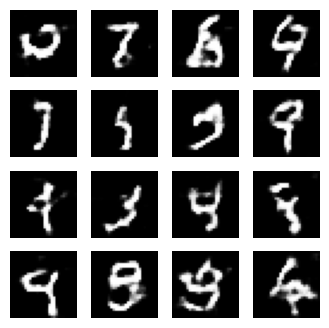

Epoch 11/50 | Gen Loss: 0.7327 | Disc Loss: 1.3511 | Time: 21.25s
Epoch 12/50 | Gen Loss: 0.7290 | Disc Loss: 1.3567 | Time: 21.24s
Epoch 13/50 | Gen Loss: 0.7261 | Disc Loss: 1.3591 | Time: 21.18s
Epoch 14/50 | Gen Loss: 0.7276 | Disc Loss: 1.3586 | Time: 21.14s
Epoch 15/50 | Gen Loss: 0.7240 | Disc Loss: 1.3581 | Time: 21.15s
Epoch 16/50 | Gen Loss: 0.7240 | Disc Loss: 1.3598 | Time: 21.16s
Epoch 17/50 | Gen Loss: 0.7338 | Disc Loss: 1.3556 | Time: 21.16s
Epoch 18/50 | Gen Loss: 0.7244 | Disc Loss: 1.3563 | Time: 21.19s
Epoch 19/50 | Gen Loss: 0.7250 | Disc Loss: 1.3554 | Time: 21.21s
Epoch 20/50 | Gen Loss: 0.7401 | Disc Loss: 1.3494 | Time: 21.23s


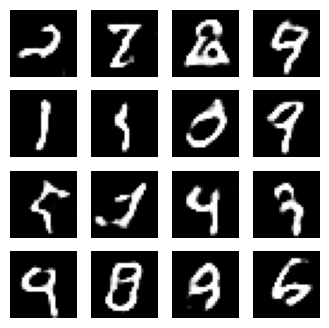

Epoch 21/50 | Gen Loss: 0.7345 | Disc Loss: 1.3506 | Time: 21.21s
Epoch 22/50 | Gen Loss: 0.7278 | Disc Loss: 1.3524 | Time: 21.23s
Epoch 23/50 | Gen Loss: 0.7338 | Disc Loss: 1.3489 | Time: 21.22s
Epoch 24/50 | Gen Loss: 0.7497 | Disc Loss: 1.3456 | Time: 21.27s
Epoch 25/50 | Gen Loss: 0.7318 | Disc Loss: 1.3487 | Time: 21.24s
Epoch 26/50 | Gen Loss: 0.7447 | Disc Loss: 1.3467 | Time: 21.24s
Epoch 27/50 | Gen Loss: 0.7471 | Disc Loss: 1.3406 | Time: 21.20s
Epoch 28/50 | Gen Loss: 0.7371 | Disc Loss: 1.3464 | Time: 21.23s
Epoch 29/50 | Gen Loss: 0.7377 | Disc Loss: 1.3457 | Time: 21.24s
Epoch 30/50 | Gen Loss: 0.7544 | Disc Loss: 1.3419 | Time: 21.22s


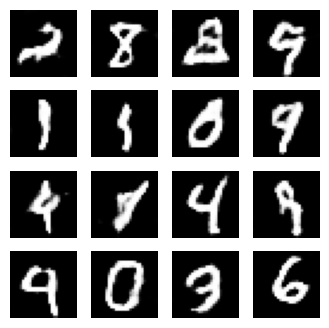

Epoch 31/50 | Gen Loss: 0.7505 | Disc Loss: 1.3410 | Time: 21.20s
Epoch 32/50 | Gen Loss: 0.7360 | Disc Loss: 1.3497 | Time: 21.20s
Epoch 33/50 | Gen Loss: 0.7348 | Disc Loss: 1.3514 | Time: 21.18s
Epoch 34/50 | Gen Loss: 0.7377 | Disc Loss: 1.3508 | Time: 21.19s
Epoch 35/50 | Gen Loss: 0.7639 | Disc Loss: 1.3396 | Time: 21.20s
Epoch 36/50 | Gen Loss: 0.7409 | Disc Loss: 1.3506 | Time: 21.16s
Epoch 37/50 | Gen Loss: 0.7340 | Disc Loss: 1.3529 | Time: 21.20s
Epoch 38/50 | Gen Loss: 0.7342 | Disc Loss: 1.3534 | Time: 21.20s
Epoch 39/50 | Gen Loss: 0.7450 | Disc Loss: 1.3492 | Time: 21.52s
Epoch 40/50 | Gen Loss: 0.7517 | Disc Loss: 1.3508 | Time: 21.22s


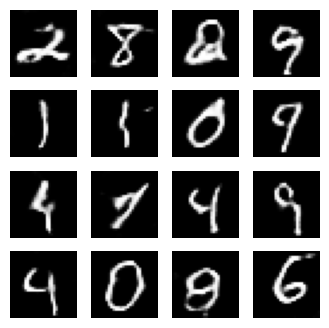

Epoch 41/50 | Gen Loss: 0.7330 | Disc Loss: 1.3537 | Time: 21.24s
Epoch 42/50 | Gen Loss: 0.7316 | Disc Loss: 1.3569 | Time: 21.29s
Epoch 43/50 | Gen Loss: 0.7346 | Disc Loss: 1.3572 | Time: 21.28s
Epoch 44/50 | Gen Loss: 0.7537 | Disc Loss: 1.3502 | Time: 21.23s
Epoch 45/50 | Gen Loss: 0.7333 | Disc Loss: 1.3552 | Time: 21.24s
Epoch 46/50 | Gen Loss: 0.7296 | Disc Loss: 1.3582 | Time: 21.25s
Epoch 47/50 | Gen Loss: 0.7296 | Disc Loss: 1.3593 | Time: 21.26s
Epoch 48/50 | Gen Loss: 0.7421 | Disc Loss: 1.3557 | Time: 21.18s
Epoch 49/50 | Gen Loss: 0.7410 | Disc Loss: 1.3541 | Time: 21.16s
Epoch 50/50 | Gen Loss: 0.7279 | Disc Loss: 1.3590 | Time: 21.18s


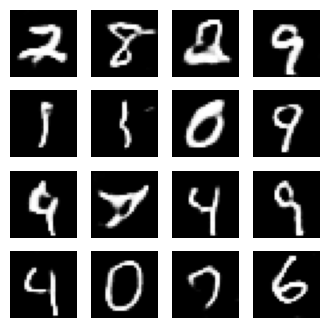

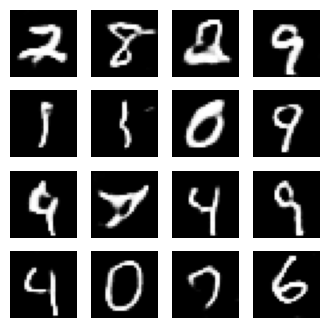

Training finished! Check the saved PNG files.


In [19]:
print("Starting GAN training...")
train(train_dataset, EPOCHS)

# Generate New images After Training Images

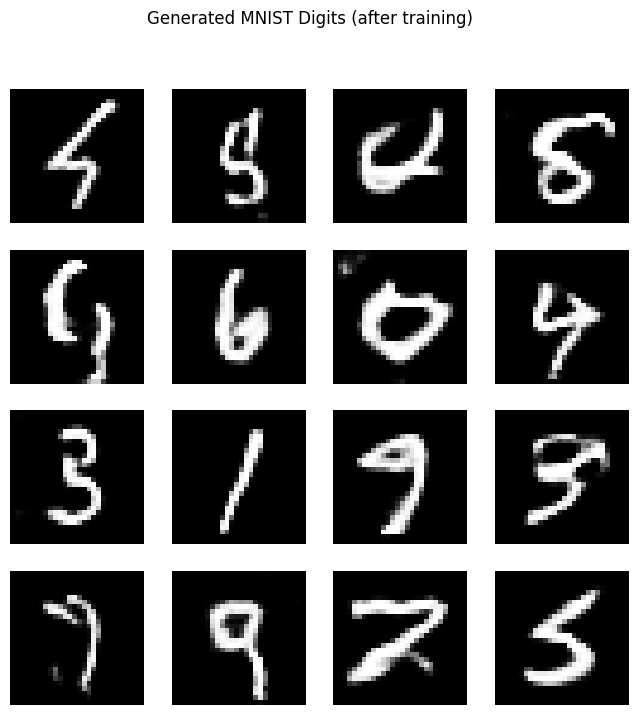

In [20]:
# You can run this anytime after training
noise = tf.random.normal([16, NOISE_DIM])
generated_images = generator(noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')
plt.suptitle('Generated MNIST Digits (after training)')
plt.show()